# loading the data

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

path_pasp = "../data/processed/pasp_df.csv" 

pasp_df = pd.read_csv(path_pasp, index_col=0)

spectral_cols = pasp_df.columns[7:]
wav = spectral_cols.astype(float)



# Autozero plot

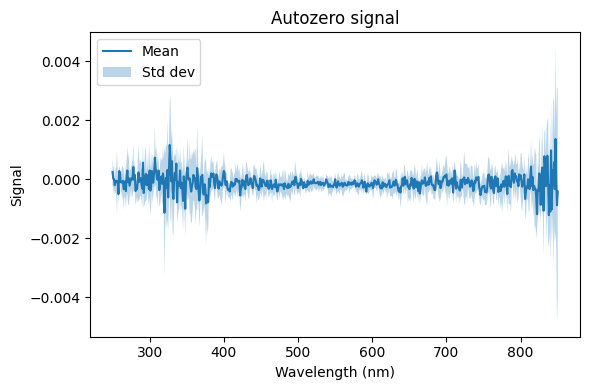

In [3]:


# --- prepare data ---
autozero_df = pasp_df[pasp_df["sampletype"] == "autozero"]
autozero_df_mean = autozero_df[spectral_cols].mean()
autozero_df_std  = autozero_df[spectral_cols].std()

# plot

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))
sns.lineplot(x=wav, y=autozero_df_mean, ax=ax, label="Mean")
ax.fill_between(
    wav,
    autozero_df_mean - autozero_df_std,
    autozero_df_mean + autozero_df_std,
    alpha=0.3,
    label="Std dev",
)
ax.set_title("Autozero signal")
ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel("Signal")
ax.legend()
plt.tight_layout()
plt.show()

Blanks plots

C:\Users\pierr\AppData\Local\Temp\ipykernel_292\1310074761.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  blk_04u = pasp_df[pasp_df["sampletype"] == "blank"][pasp_df["filtertype"] == "04u"]
C:\Users\pierr\AppData\Local\Temp\ipykernel_292\1310074761.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  blk_14u = pasp_df[pasp_df["sampletype"] == "blank"][pasp_df["filtertype"] == "14u"]
C:\Users\pierr\AppData\Local\Temp\ipykernel_292\1310074761.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1, 0].legend()
C:\Users\pierr\AppData\Local\Temp\ipykernel_292\1310074761.py:60: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1, 1].legend()


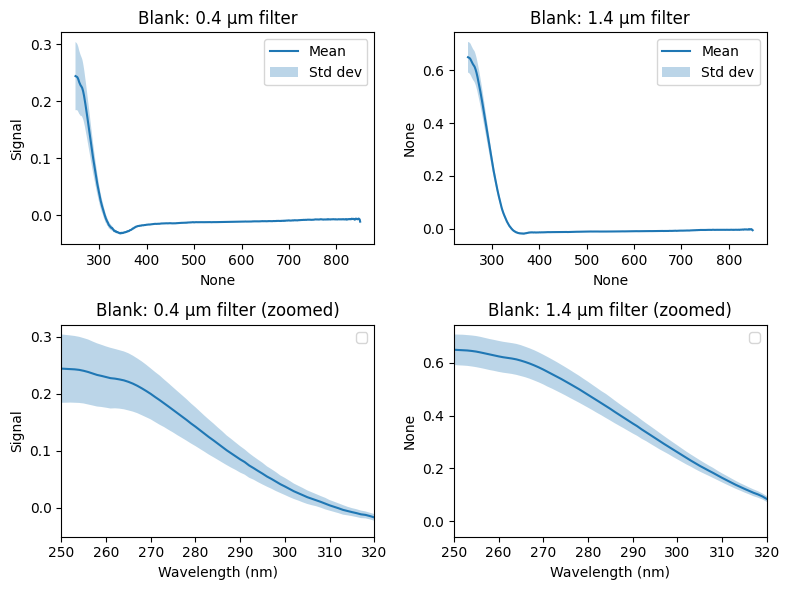

In [4]:
# --- prepare data ---
blk_04u = pasp_df[pasp_df["sampletype"] == "blank"][pasp_df["filtertype"] == "04u"]
blk_14u = pasp_df[pasp_df["sampletype"] == "blank"][pasp_df["filtertype"] == "14u"]

blk_04u_mean = blk_04u[spectral_cols].mean(numeric_only=True)
blk_04u_std  = blk_04u[spectral_cols].std(numeric_only=True)

blk_14u_mean = blk_14u[spectral_cols].mean(numeric_only=True)
blk_14u_std  = blk_14u[spectral_cols].std(numeric_only=True)

# --- figure ---
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(8, 6))

# ===== Full spectra =====
sns.lineplot(x=wav, y=blk_04u_mean, ax=ax[0, 0], label="Mean")
ax[0, 0].fill_between(
    wav,
    blk_04u_mean - blk_04u_std,
    blk_04u_mean + blk_04u_std,
    alpha=0.3,
    label="Std dev",
)
ax[0, 0].set_title("Blank: 0.4 µm filter")
ax[0, 0].legend()

sns.lineplot(x=wav, y=blk_14u_mean, ax=ax[0, 1], label="Mean")
ax[0, 1].fill_between(
    wav,
    blk_14u_mean - blk_14u_std,
    blk_14u_mean + blk_14u_std,
    alpha=0.3,
    label="Std dev",
)
ax[0, 1].set_title("Blank: 1.4 µm filter")
ax[0, 1].legend()

# ===== Zoomed spectra =====
sns.lineplot(x=wav, y=blk_04u_mean, ax=ax[1, 0])
ax[1, 0].fill_between(
    wav,
    blk_04u_mean - blk_04u_std,
    blk_04u_mean + blk_04u_std,
    alpha=0.3,
)
ax[1, 0].set_xlim(250, 320)
ax[1, 0].set_xlabel("Wavelength (nm)")
ax[1, 0].set_title("Blank: 0.4 µm filter (zoomed)")
ax[1, 0].legend()

sns.lineplot(x=wav, y=blk_14u_mean, ax=ax[1, 1])
ax[1, 1].fill_between(
    wav,
    blk_14u_mean - blk_14u_std,
    blk_14u_mean + blk_14u_std,
    alpha=0.3,
)
ax[1, 1].set_xlim(250, 320)
ax[1, 1].set_xlabel("Wavelength (nm)")
ax[1, 1].set_title("Blank: 1.4 µm filter (zoomed)")
ax[1, 1].legend()

# --- layout ---
for a in ax[:, 0]:
    a.set_ylabel("Signal")

plt.tight_layout()
plt.show()


**Comment on the figure**: the blank measurements stayed consistend throughout the whole experiment, as shown by a low standard deviation accross the spectro collected over different days. A larger deviation is observed in the UV region, showing that higher uncertainties needs to be accounted for in this region. 

The autozero spectra are also consistently close to zero and noise (+/- 0.002) is 50 times lower than the blank signal. 

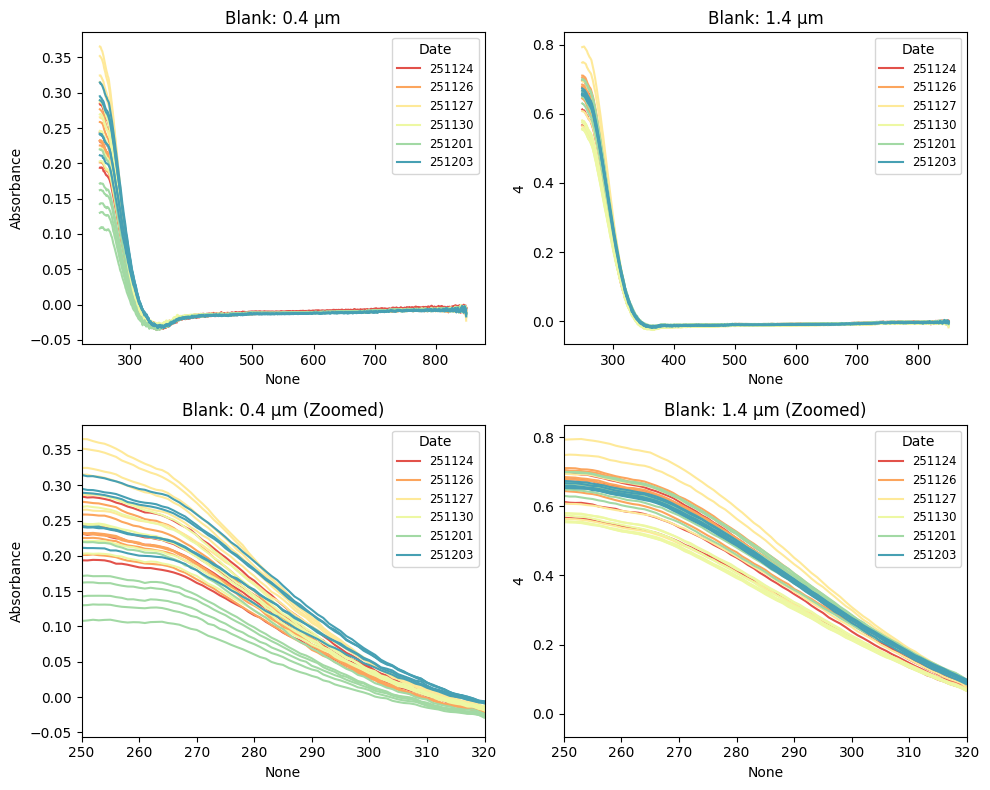

In [8]:

unique_dates = pasp_df["datestr"].unique()
colors = sns.color_palette("Spectral", len(unique_dates))
date_color_map = dict(zip(unique_dates, colors))

# --- figure ---
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))

for s in pasp_df["sample_name"].unique():
    # Extract row and date
    sample_row = pasp_df[pasp_df["sample_name"] == s]
    date_val = sample_row["datestr"].iloc[0]
    plot_color = date_color_map[date_val]
    
    # Get the spectrum data (columns 7 onwards)
    spectrum = sample_row.iloc[0, 7:]
    
    # Logic for subplots
    if "blk" in s:
        if "04u" in s:
            target_axes = [ax[0, 0], ax[1, 0]]
        elif "14u" in s:
            target_axes = [ax[0, 1], ax[1, 1]]
        else:
            continue
            
        for a in target_axes:
            sns.lineplot(ax=a, x=wav, y=spectrum, color=plot_color, label=date_val)

# --- Cleanup Legends ---
# Since we plot in a loop, the legend will have many duplicates. 
# This helper removes duplicate labels.
for a in ax.flatten():
    handles, labels = a.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    a.legend(by_label.values(), by_label.keys(), title="Date", fontsize='small')

# --- Formatting ---
ax[1, 1].set_xlim(250, 320)
ax[1, 0].set_xlim(250, 320)
ax[0, 0].set_title("Blank: 0.4 µm")
ax[0, 1].set_title("Blank: 1.4 µm")
ax[1, 0].set_title("Blank: 0.4 µm (Zoomed)")
ax[1, 1].set_title("Blank: 1.4 µm (Zoomed)")

for a in ax[:, 0]:
    a.set_ylabel("Absorbance")

plt.tight_layout()
plt.show()